In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

In [2]:
def count_edges(G):
    return sum(len(neighbors) for neighbors in G.adj.values()) // 2

def is_bipartite(G):
    color = {}
    for start_node in G.nodes():
        if start_node not in color:
            stack = [(start_node, 0)]
            while stack:
                node, c = stack.pop()
                if node in color:
                    if color[node] != c:
                        return False
                else:
                    color[node] = c
                    stack.extend((neighbor, 1 - c) for neighbor in G.adj[node])
    return True

def find_diameter(G):
    if not nx.is_connected(G):
        return float('inf')  # or return None, depending on your needs
    def bfs(start):
        distances = {start: 0}
        queue = [start]
        while queue:
            node = queue.pop(0)
            for neighbor in G.adj[node]:
                if neighbor not in distances:
                    distances[neighbor] = distances[node] + 1
                    queue.append(neighbor)
        return max(distances.values())
    
    return max(bfs(node) for node in G.nodes())

def find_max_clique(G):
    def is_clique(nodes):
        return all(v in G.adj[u] for u in nodes for v in nodes if u != v)

    def backtrack(candidates, clique):
        if not candidates:
            return clique
        v = max(candidates, key=lambda x: len(G.adj[x]))
        candidates.remove(v)  # Remove v to avoid checking it again
        new_clique = clique | {v}
        for u in list(candidates):  # Create a list to avoid modification during iteration
            if not all(u in G.adj[w] for w in new_clique):
                candidates.remove(u)
        return max((backtrack(candidates.copy(), new_clique), clique), key=len)

    return len(backtrack(set(G.nodes()), set()))

def average_clustering(G):
    def local_clustering(node):
        neighbors = list(G.adj[node])
        if len(neighbors) < 2:
            return 0
        links = sum(1 for u in neighbors for v in neighbors if u < v and v in G.adj[u])
        possible_links = len(neighbors) * (len(neighbors) - 1) / 2
        return links / possible_links if possible_links > 0 else 0
    
    if len(G.nodes()) == 0:
        return 0
    return sum(local_clustering(node) for node in G.nodes()) / len(G.nodes())

def estimate_group_size(G):
    degree_counts = defaultdict(int)
    for node in G.nodes():
        degree_counts[len(G.adj[node])] += 1
    return max(degree_counts.values()) if degree_counts else 0

def estimate_orbit_count(G):
    return len(set(len(G.adj[node]) for node in G.nodes()))

In [3]:
edge_counts = []
bipartite_counts = defaultdict(int)
diameters = []
clique_numbers = []
degrees = []
clustering_coefficients = []
group_sizes = []
orbit_counts = []
plots_folder = '../data/plots/'

with open('../data/graphs/negative_graphs.g6', 'r') as file:
    for line in file:
        try:
            G = nx.from_graph6_bytes(line.strip().encode('utf-8'))

            edge_counts.append(count_edges(G))
            bipartite_counts[is_bipartite(G)] += 1
            
            if nx.is_connected(G):
                diameters.append(find_diameter(G))
            
            clique_number = find_max_clique(G)
            clique_numbers.append(clique_number)

            degrees.extend(G.degree(node) for node in G.nodes())
            clustering_coefficients.append(average_clustering(G))

            group_sizes.append(estimate_group_size(G))
            orbit_counts.append(estimate_orbit_count(G))

        except nx.NetworkXError as e:
            print(f"Error processing graph: {e}")

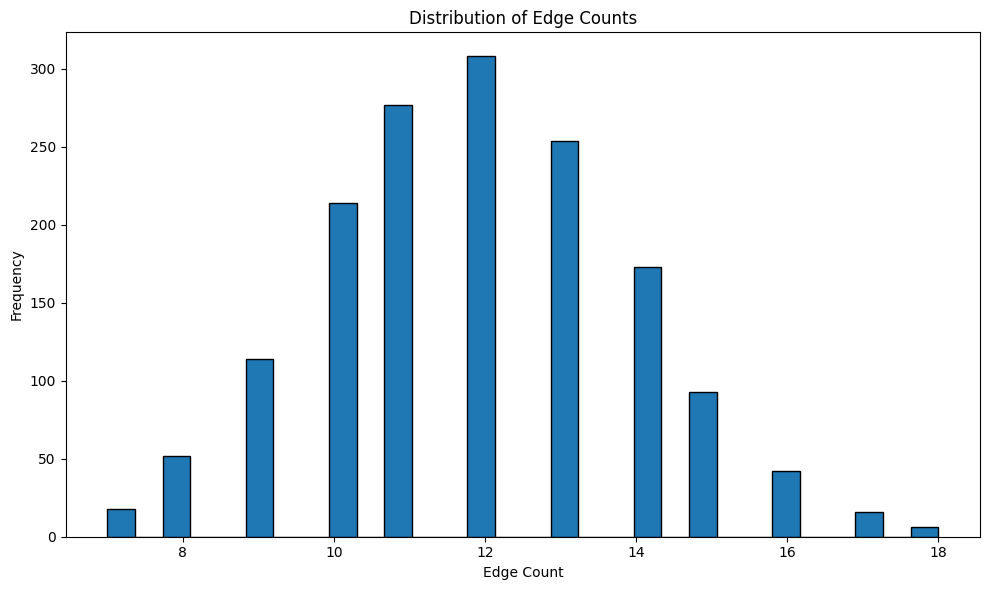

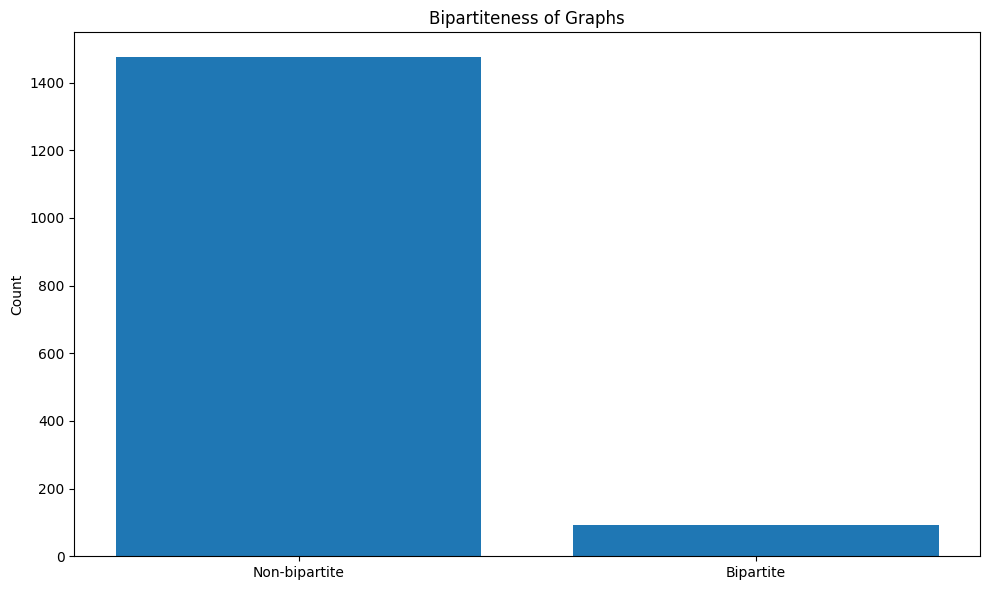

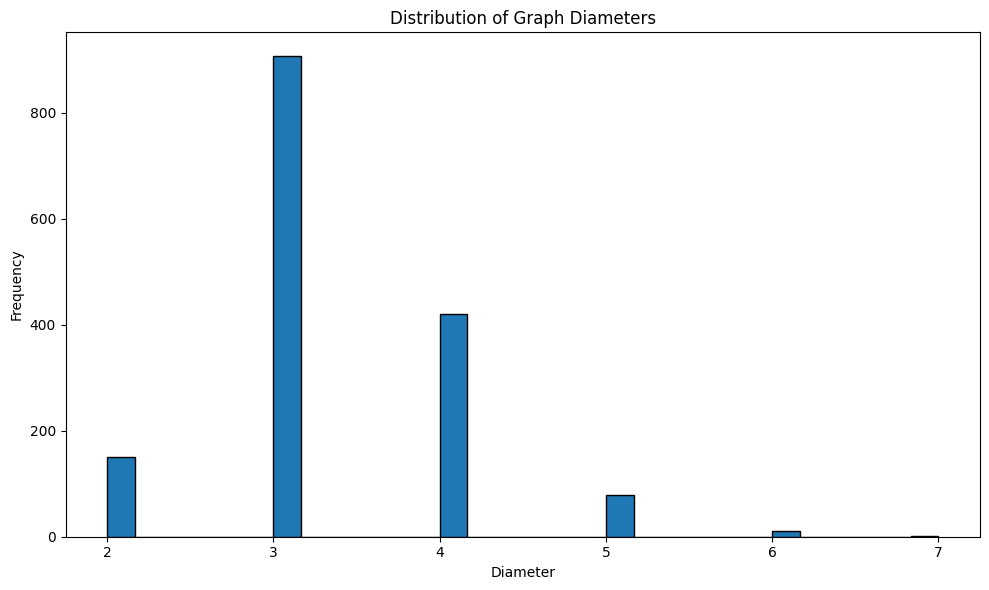

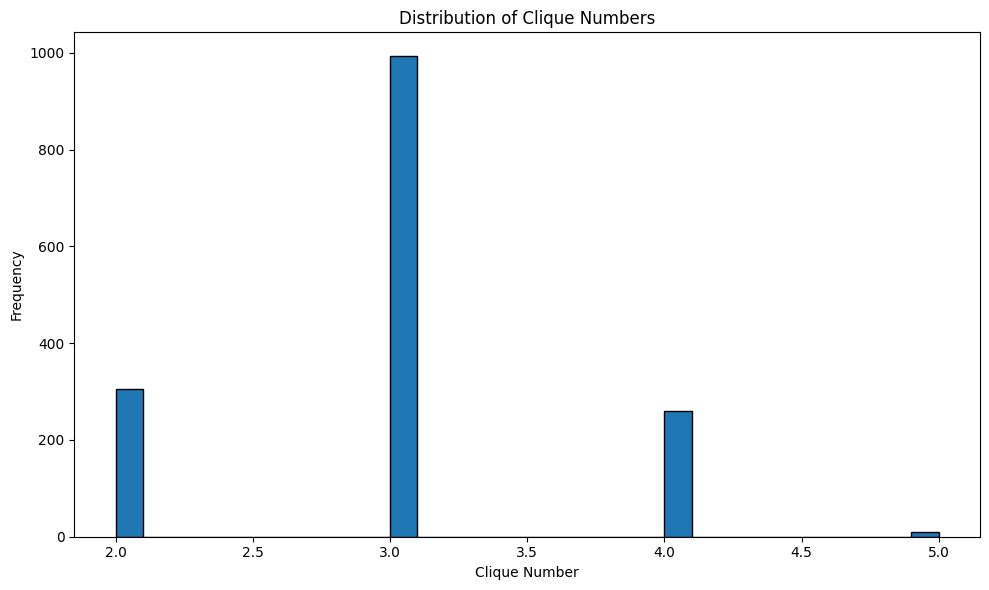

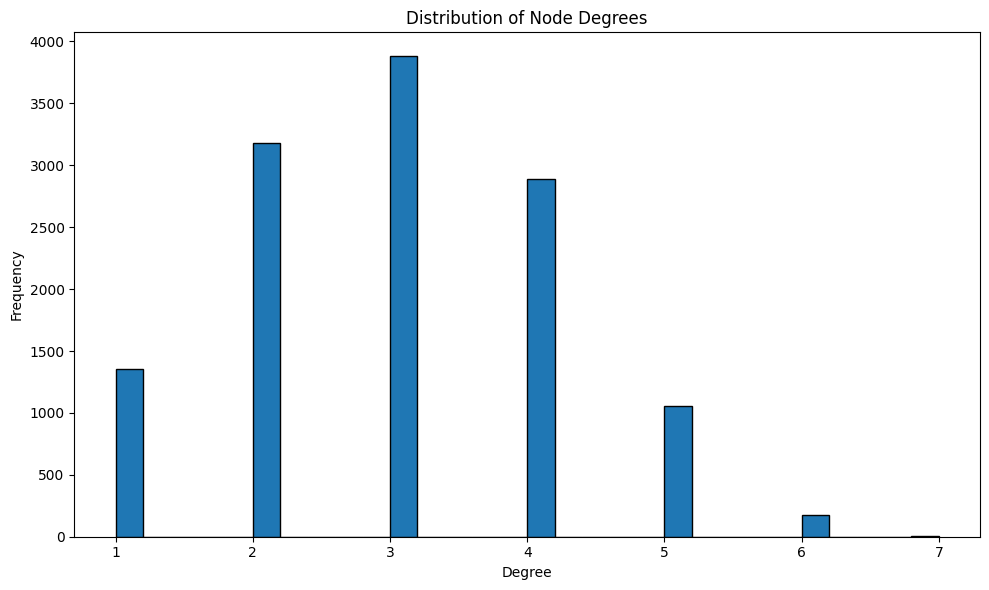

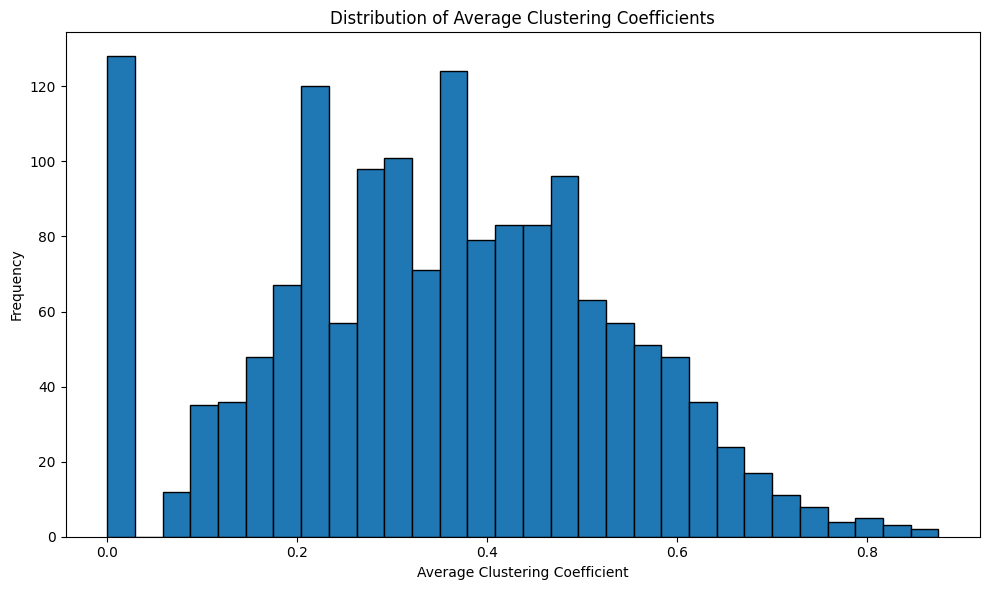

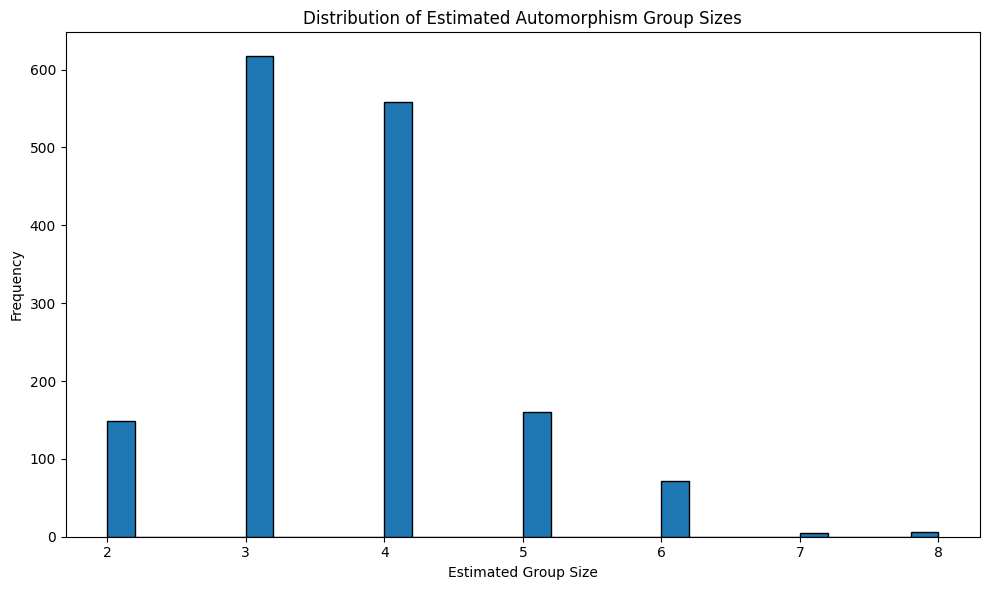

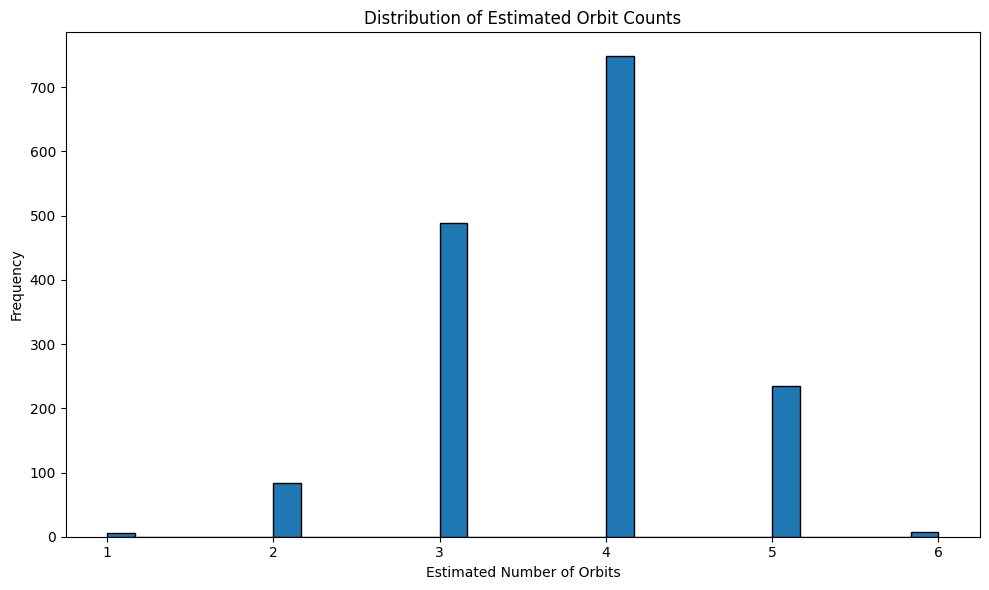

In [4]:
# Plotting functions
def plot_histogram(data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=30, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

def plot_bar(data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(10, 6))
    plt.bar(data.keys(), data.values())
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks([0, 1], ['Non-bipartite', 'Bipartite'])
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Generate plots
plot_histogram(edge_counts, 'Distribution of Edge Counts', 'Edge Count', 'Frequency', plots_folder+'edge_counts.pdf')
plot_bar(bipartite_counts, 'Bipartiteness of Graphs', '', 'Count', plots_folder+'bipartiteness.pdf')
plot_histogram(diameters, 'Distribution of Graph Diameters', 'Diameter', 'Frequency', plots_folder+'diameters.pdf')
plot_histogram(clique_numbers, 'Distribution of Clique Numbers', 'Clique Number', 'Frequency', plots_folder+'clique_numbers.pdf')
plot_histogram(degrees, 'Distribution of Node Degrees', 'Degree', 'Frequency', plots_folder+'degrees.pdf')
plot_histogram(clustering_coefficients, 'Distribution of Average Clustering Coefficients', 'Average Clustering Coefficient', 'Frequency', plots_folder+'clustering_coefficients.pdf')
plot_histogram(group_sizes, 'Distribution of Estimated Automorphism Group Sizes', 'Estimated Group Size', 'Frequency', plots_folder+'group_sizes.pdf')
plot_histogram(orbit_counts, 'Distribution of Estimated Orbit Counts', 'Estimated Number of Orbits', 'Frequency', plots_folder+'orbit_counts.pdf')

In [5]:
print(f"Total graphs processed: {len(edge_counts)}")
print(f"Edge count - Min: {min(edge_counts)}, Max: {max(edge_counts)}, Mean: {np.mean(edge_counts):.2f}")
print(f"Bipartite graphs: {bipartite_counts[True]}, Non-bipartite graphs: {bipartite_counts[False]}")
print(f"Diameter - Min: {min(diameters)}, Max: {max(diameters)}, Mean: {np.mean(diameters):.2f}")
print(f"Clique number - Min: {min(clique_numbers)}, Max: {max(clique_numbers)}, Mean: {np.mean(clique_numbers):.2f}")
print(f"Degree - Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.2f}")
print(f"Clustering coefficient - Min: {min(clustering_coefficients)}, Max: {max(clustering_coefficients)}, Mean: {np.mean(clustering_coefficients):.2f}")
print(f"Estimated group size - Min: {min(group_sizes)}, Max: {max(group_sizes)}, Mean: {np.mean(group_sizes):.2f}")
print(f"Estimated orbit count - Min: {min(orbit_counts)}, Max: {max(orbit_counts)}, Mean: {np.mean(orbit_counts):.2f}")

Total graphs processed: 1567
Edge count - Min: 7, Max: 18, Mean: 11.88
Bipartite graphs: 92, Non-bipartite graphs: 1475
Diameter - Min: 2, Max: 7, Mean: 3.29
Clique number - Min: 2, Max: 5, Mean: 2.98
Degree - Min: 1, Max: 7, Mean: 2.97
Clustering coefficient - Min: 0.0, Max: 0.875, Mean: 0.35
Estimated group size - Min: 2, Max: 8, Mean: 3.64
Estimated orbit count - Min: 1, Max: 6, Mean: 3.73
